In [ ]:
using Plots, LaTeXStrings, CSV, DataFrames, Colors
const path = @__DIR__
theme(:dark)

### **QUIZ 2 ELECTRÓNICA**

---
---
---


### **EJERCICIO 1: Teoremas de Análisis de Circuitos**
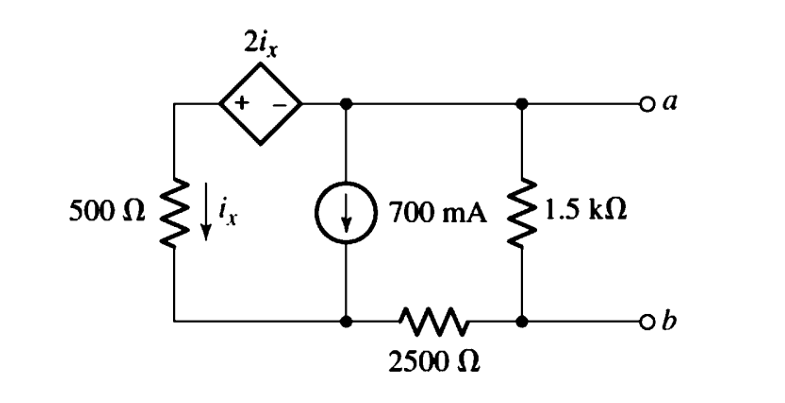


---

Queremos encontrar $V_{ab} = V_{R_{1500}}$ y la potencia en la fuente independiente $P_I$.

Realizamos dos mallas de izquierda a derecha: $I_1 = i_x$ en sentido horario, $I_2$ en sentido antihorario. Un breve análisis muestra que $I = I_1 + I_2$.

Haciendo L.K.V en las mallas, obetenemos 

$$
I_1: \ \ \ \ V_{I} - V_{R_{500}} - V_{2i_x} = 0 \implies V_I - 500i_x - 2i_x = 0 \implies V_I = 502i_x
$$
$$
I_2: \ \ \ \ V_{I} - V_{R_{2500}} - V_{R_{1500}} = 0 \implies V_I - 1500I_2 - 2500I_2 \implies V_I = 4000I_2
$$

Luego, igualando estas ecuaciones en $V_I$, tenemos $I_2 = \frac{502i_x}{4000}$, entonces,

$$
I = i_x + \frac{502i_x}{4000} \implies i_x = \frac{I}{1+\frac{502}{4000}} = \frac{700}{1+\frac{502}{4000}} = 621.94 \ [mA] 
$$
$$
\therefore i_x \approx 0.622 \ [A]
$$
$$
I_2 = I - i_x = 700 - 621.94 = 78.05 \ [mA] 
$$
$$
\therefore I_2 \approx 0.078 \ [A]
$$

Así, $V_I = 502i_x = 502(0.622) \approx 312.24 \ [V]$. Por lo tanto,

$$
P_I = V_I I = 312.24*0.7
$$
$$
\boxed{\therefore P_I = 218.57\ [W]}
$$

Y, finalmente,

$$
V_{ab} = V_{R_{1500}} = R_{1500}*I_2 = 1500\Omega * 0.078 [A]
$$
$$
\boxed{\therefore V_{ab} \approx 117 \ [V] }
$$

---

**Resultado de Altium:** (Discrepacia proveniente de las aproximaciones analíticas)

$V_{ab} = 117.08 \ [V]$ 


---
---

### **EJERCICIO 2: Circuitos de Primer Orden con Elementos Dinámicos**
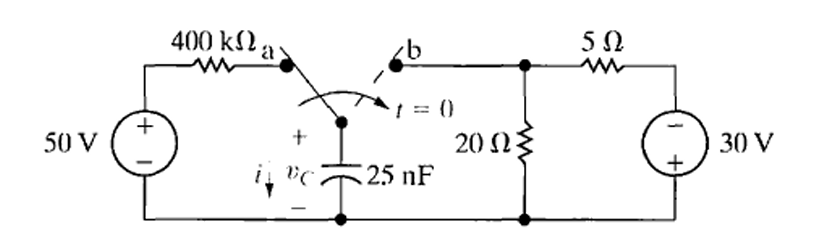



---

**PARTE 1: Circuito en $a$**

Si llevamos mucho tiempo en $a$ podemos tomar el capacitor como un circuito abierto. Lo que implica que $V_C(0^-) = V_C(0^+) = V_{S1} = 50 \ [V]$

**PARTE 2: Circuito en $b$**

Nótese que el circuito a la derecha del switche se puede reducir a una fuente de voltaje $V_{S2} = 24 \ [V]$ y una resistencia equivalente $R_{eq} = 4 \ [\Omega]$. 

Por lo que $\tau = R_{eq}C = 4*25 \ [\Omega nF] \implies \boxed{\tau = 100 \ [ns]}$

Ahora,  tomando en cuenta la reducción de Thévenin que realizamos, podemos encontrar la ecuación diferencial asociada

$$
V_C + I_cR_{eq} + V_{S2} = 0 \iff V_C + \tau \frac{dV_c}{dt} + V_{S2} = 0 \iff \frac{dV_C}{dt} + \frac{V_C}{\tau} = -\frac{V_{S2}}{\tau} 
$$

Cuyo factor integrante es $\mu(t) = e^{\frac{t}{\tau}}$, por lo tanto

$$
\mu(t)V_C = -24\mu(t) + K \iff V_C = -24 + Ke^{-\frac{t}{\tau}}
$$

Evaluando la condición de frontera $V_C(0) = 50 \ [V]$, encontramos $K = 74 \ [V]$

$$
\boxed{\therefore V_C(t) = 74e^{-10^7t} - 24 \ \ [V]}
$$


---

**GRAFICA CON LOS DATOS DE LA SIMULACIÓN:**

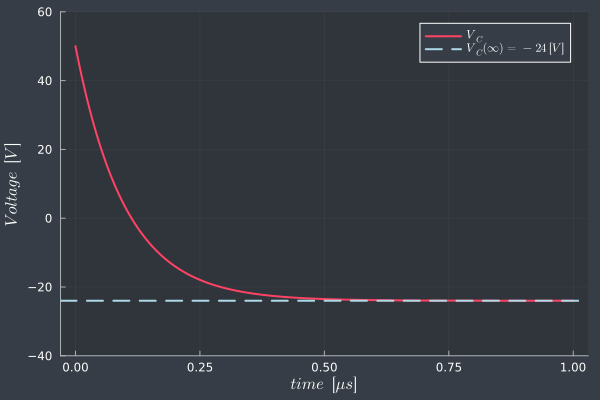

In [ ]:
#Importamos datos de Altium:
data1 = CSV.read(path*"/DATA/Quiz2_Altium_circ2.csv", DataFrame)
t = data1.s
VC = data1.V_C

plot(t .* 1e6, VC, 
    xlabel = L"time \ \ [\mu s]", ylabel = L"Voltage \ \ [V]", label = L"V_C",
    ylims = (-40, 60), lw = 2)
p1 = hline!([-24], label = L"V_C(\infty) = -24 \ [V]", lw = 2, ls = :dash, color = :lightblue)

savefig(p1, path*"/PLOTS/circuito2.png")
p1

---
---

### **EJERCICIO 3: Circuitos de Segundo Orden con Elementos Dinámicos**

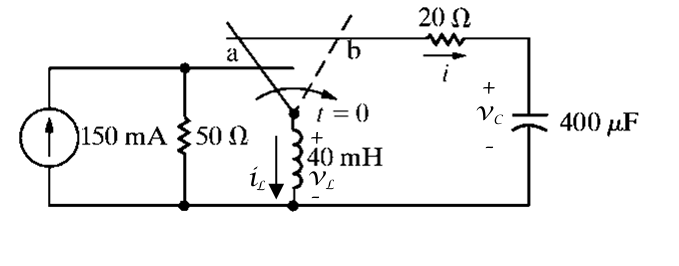

---

**PARTE 1: Circuito en $a$**

Dado que el circuito lleva mucho tiempo en $a$, sabemos que el inductor y el capacitor se comportan como un corto y un circuito abierto, respectivamente. 

Así, sabemos que $V_C(0^-) = V_C(0^+) = V_L(0^-) = 0 \ [V]; \ \ I_L(0^-) = I_L(0^+) = I_S = 150 \ [mA]$

**PARTE 2: Circuito en $b$**

Cuando pasamos a $b$ en $t = 0$, notamos que $I_L = -I$. Adicionalmente, podemos calcular $V_L(0^+)$ con L.K.V en $t = 0^+$

$$
V_C(0^+) - V_{R_{20}}(0^+) - V_L(0^+) = 0 \iff V_L(0^+) = V_C(0^+) - V_{R_{20}}(0^+) = 0 - R_{20}*I_L(0^+) = -20*0.15 = -3
$$

$$
\therefore V_L(0^+) = -3 \ [V]
$$

Ahora, con una L.K.V con corriente en sentido horario para $t > 0$

$$
V_L + V_{R_{20}} + V_C = 0 \implies L\frac{dI}{dt} + IR_{20} + \frac{1}{C}(\int I dt + V_0) = 0 
$$

Lo que entrega la ecuación diferencial 
$$
\frac{d^2I}{dt^2} + \frac{R_{20}}{L}\frac{dI}{dt} + \frac{1}{CL}I = 0  \implies \frac{d^2I}{dt^2} + 500\frac{dI}{dt} + 62500I = 0 
$$

Sea $I(t) = e^{rt}$, entonces 

$$
r^2 + 500r + 62500 = 0 \implies r = -250 \ \ \text{(Críticamente amortiguado)}
$$
$$
\implies I(t) = Ae^{-250t} + Bte^{-250t} \ \ \mid t \ge 0
$$
$$
\implies V_L(t) = -10(Ae^{-250t} + Bte^{-250t}) + 0.04Be^{-250t} \ \  \mid t > 0 
$$

Evaluando las condiciones iniciales,

$$I(0^+) = -I_L(0^+) = -0.15 \ [A] \implies A = -0.15$$
$$-V_L(0^+) = -L\frac{dI_L}{dt}(0^+) = L\frac{dI}{dt}(0^+) = 3 \implies B = 37.5$$

Y, finalmente,

$$
\boxed{\therefore I(t) = -0.15e^{-250t} + 37.5te^{-250t} \ [A]}
$$




---

**GRAFICA CON LOS DATOS DE LA SIMULACIÓN:**

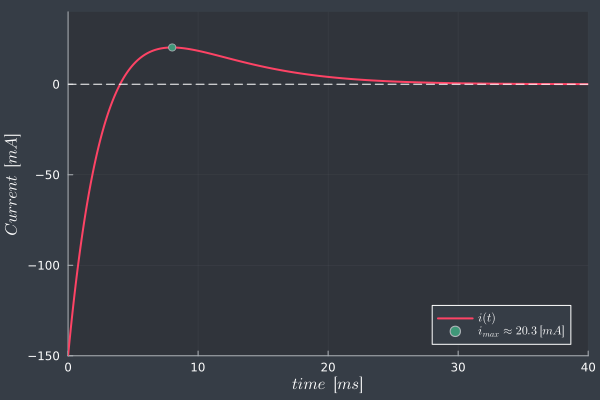

In [ ]:
#Importamos datos de Altium:
data2 = CSV.read(path*"/DATA/Quiz2_Altium_circ3.csv", DataFrame)
t = data2.s .* 1e3#ms
i = data2.I .* 1e3#mA

plot(t, i, 
    xlabel = L"time \ \ [ms]", ylabel = L"Current \ \ [mA]", label = L"i(t)",
    xlims = (0, 40), ylims = (-150, 40),
    lw = 2)
hline!([0], label = false, ls = :dash, color = :white)
p2 = scatter!([t[161]], [i[161]], label = L"i_{max} \approx 20.3 \ [mA]")

savefig(p2, path*"/PLOTS/circuito3.png")
p2